# 01 — The Big Picture: catalogue, exposure, and clicks

## 1. Purpose

Research Question 1 (**Amplification**): *Which news categories receive disproportionately high
exposure compared with their presence in the available content catalogue?*

This notebook works only with the **observed system** — the MIND small impression logs. It:

1. loads and validates `news.tsv` and `behaviors.tsv` (train + dev);
2. builds one **exposure record** per article shown in an impression;
3. compares **catalogue share → exposure share → click share** by category (Analyses A–D);
4. measures **article-level exposure concentration** (Lorenz, Gini, top-X%) and the long tail (E–F).

**Definitions** (see `CLAUDE.md`)

| Term | Definition | Denominator |
|---|---|---|
| Catalogue share | articles in category | unique articles in train ∪ dev `news.tsv` |
| Exposed-pool share | articles in category shown ≥1 time | unique articles shown ≥1 time |
| Exposure share | impressions in category | all impressions (train + dev) |
| Click share | clicks in category | all clicks |
| CTR | clicks in category | impressions in category |
| Exposure amplification | exposure share / catalogue share | — (1 = proportional) |

An *impression* is a logged exposure proxy, not proof of attention. A *click* is an engagement signal.

## 2. Setup

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data as D
from src import metrics as M

SOURCE = "notebooks/01_big_picture.ipynb"
OUT = D.output_dir()
RESULTS, FIGURES = OUT / "results", OUT / "figures"
RESULTS.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)
reg = M.HeadlineRegistry(SOURCE)

pd.set_option("display.width", 160, "display.max_columns", 30, "display.float_format", "{:,.4f}".format)

# Visual system (validated categorical slots 1-3; text in ink, never series colour)
C_CAT, C_EXP, C_CLK = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False,
})
print("data dir:", D.data_dir()); print("output dir:", OUT)

data dir: /Users/lionaelsmac/information-diversity/data/raw
output dir: /Users/lionaelsmac/information-diversity/outputs


## 3. Data loading

In [2]:
files = D.check_files()
files

,split,file,path,exists,size_mb
0,train,news.tsv,/Users/lionaelsmac/information-diversity/data/...,True,41.2000
1,train,behaviors.tsv,/Users/lionaelsmac/information-diversity/data/...,True,92.0000
2,dev,news.tsv,/Users/lionaelsmac/information-diversity/data/...,True,33.5000
3,dev,behaviors.tsv,/Users/lionaelsmac/information-diversity/data/...,True,42.8000


In [3]:
SPLITS = ["train", "dev"]
news = {s: D.load_news(s) for s in SPLITS}
beh = {s: D.load_behaviors(s) for s in SPLITS}
for s in SPLITS:
    print(f"{s:5s}  news.tsv rows = {len(news[s]):>9,}   behaviors.tsv rows = {len(beh[s]):>9,}")

train  news.tsv rows =    51,282   behaviors.tsv rows =   156,965
dev    news.tsv rows =    42,416   behaviors.tsv rows =    73,152


In [4]:
display(news["train"].head(3))
display(beh["train"].head(3))

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities,split
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],train
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",train
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...",train


,impression_id,user_id,time,history,impressions,split,imp_key
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,train,train-1
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,train,train-2
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,train,train-3


## 4. Data validation

Checks: schema, row counts, missing values, duplicate IDs, impression structure, label validity,
joinability of shown and history articles to `news.tsv`, user overlap across splits, and whether a
user's `history` changes over time (relevant to Notebook 02's temporal design).

In [5]:
news_val = pd.DataFrame({s: D.validate_news(news[s]) for s in SPLITS})
news_val

,train,dev
rows,51282,42416
columns_ok,True,True
unique_news_ids,51282,42416
duplicate_news_ids,0,0
missing_by_column,"{'news_id': 0, 'category': 0, 'subcategory': 0...","{'news_id': 0, 'category': 0, 'subcategory': 0..."
n_categories,17,17
n_subcategories,264,257
bad_id_format,0,0


In [6]:
catalogue, conflicts = D.load_catalogue(SPLITS)
print(f"Catalogue (train ∪ dev news.tsv): {len(catalogue):,} unique articles")
print(catalogue["in_splits"].value_counts().to_string())
print(f"Articles with conflicting category/subcategory/title across splits: {conflicts['news_id'].nunique()}")

Catalogue (train ∪ dev news.tsv): 65,238 unique articles
in_splits
dev,train    28460
train        22822
dev          13956
Articles with conflicting category/subcategory/title across splits: 0


In [7]:
exp_by_split = {s: D.explode_impressions(beh[s]) for s in SPLITS}
beh_val = pd.DataFrame({s: D.validate_behaviors(beh[s], exp_by_split[s]) for s in SPLITS})
beh_val

,train,dev
rows,156965,73152
columns_ok,True,True
duplicate_impression_ids,0,0
unique_users,50000,50000
missing_by_column,"{'impression_id': 0, 'user_id': 0, 'time': 0, ...","{'impression_id': 0, 'user_id': 0, 'time': 0, ..."
time_min,2019-11-09 00:00:19,2019-11-15 00:00:01
time_max,2019-11-14 23:59:13,2019-11-15 23:58:03
unparseable_labels,0,0
labels_not_0_or_1,0,0
exposure_records,5843444,2740998


In [8]:
# Join coverage: shown articles and history articles vs. (a) same-split news.tsv, (b) the union catalogue
cov_rows = []
for s in SPLITS:
    hist = D.explode_history(beh[s], dedupe_per_user=False)
    for label, ids in [("impression articles", exp_by_split[s]["news_id"]), ("history articles", hist["news_id"])]:
        for ref_name, ref in [("same-split news.tsv", news[s]["news_id"]), ("union catalogue", catalogue["news_id"])]:
            cov_rows.append({"split": s, "ids": label, "reference": ref_name, **D.join_coverage(ids, ref)})
coverage = pd.DataFrame(cov_rows)
coverage

,split,ids,reference,records,records_unmatched,unique_ids,unique_ids_unmatched
0,train,impression articles,same-split news.tsv,5843444,0,20288,0
1,train,impression articles,union catalogue,5843444,0,20288,0
2,train,history articles,same-split news.tsv,5107639,0,33195,0
3,train,history articles,union catalogue,5107639,0,33195,0
4,dev,impression articles,same-split news.tsv,2740998,0,5369,0
5,dev,impression articles,union catalogue,2740998,0,5369,0
6,dev,history articles,same-split news.tsv,2362514,0,37681,0
7,dev,history articles,union catalogue,2362514,0,37681,0


In [9]:
users = {s: set(beh[s]["user_id"]) for s in SPLITS}
overlap = len(users["train"] & users["dev"])
all_users = users["train"] | users["dev"]
print(f"unique users train={len(users['train']):,}  dev={len(users['dev']):,}  "
      f"both={overlap:,}  union={len(all_users):,}")

beh_all = pd.concat([beh[s] for s in SPLITS], ignore_index=True)
hist_stab = {"within train": D.history_stability(beh["train"]),
             "within dev": D.history_stability(beh["dev"]),
             "across train+dev": D.history_stability(beh_all)}
pd.DataFrame(hist_stab)

unique users train=50,000  dev=50,000  both=5,943  union=94,057


,within train,within dev,across train+dev
users,50000,50000,94057
users_with_2plus_impressions,33617,14826,47827
users_with_varying_history,0,0,0


In [10]:
empty_hist = {s: int(beh[s]["history"].isna().sum()) for s in SPLITS}
print("impressions with empty history:", empty_hist)
for s in SPLITS:
    days = beh[s]["time"].dt.date.value_counts().sort_index()
    print(f"\n{s}: impressions per calendar day\n{days.to_string()}")

impressions with empty history: {'train': 3238, 'dev': 2214}

train: impressions per calendar day
time
2019-11-09    13570
2019-11-10    15048
2019-11-11    32799
2019-11-12    33654
2019-11-13    31624
2019-11-14    30270

dev: impressions per calendar day
time
2019-11-15    73152


In [11]:
# Collect anomalies programmatically so the list reflects what was actually observed.
anomalies = []
for s in SPLITS:
    nv, bv = news_val[s], beh_val[s]
    if nv["duplicate_news_ids"]: anomalies.append(f"{s}: {nv['duplicate_news_ids']} duplicate news_ids in news.tsv")
    if nv["bad_id_format"]: anomalies.append(f"{s}: {nv['bad_id_format']} news_ids not matching N<digits>")
    for col, n in nv["missing_by_column"].items():
        if n: anomalies.append(f"{s}: news.tsv column '{col}' missing in {n:,} rows ({n/nv['rows']:.1%})")
    for col, n in bv["missing_by_column"].items():
        if n: anomalies.append(f"{s}: behaviors.tsv column '{col}' missing in {n:,} rows ({n/bv['rows']:.1%})")
    for k in ["duplicate_impression_ids", "unparseable_labels", "labels_not_0_or_1",
              "impressions_with_no_articles", "duplicate_article_within_impression"]:
        if bv[k]: anomalies.append(f"{s}: {k} = {bv[k]:,}")
    if bv["impressions_with_zero_clicks"]:
        anomalies.append(f"{s}: {bv['impressions_with_zero_clicks']:,} impressions have zero clicks")
for _, r in coverage.iterrows():
    if r["records_unmatched"]:
        anomalies.append(f"{r['split']}: {r['ids']} not in {r['reference']}: "
                         f"{r['records_unmatched']:,} records / {r['unique_ids_unmatched']:,} unique ids")
if conflicts["news_id"].nunique():
    anomalies.append(f"{conflicts['news_id'].nunique()} articles have conflicting metadata across splits")
for k, v in hist_stab.items():
    if v["users_with_varying_history"]:
        anomalies.append(f"history varies across impressions for {v['users_with_varying_history']:,} users ({k})")
print("\n".join(f"- {a}" for a in anomalies) or "No anomalies detected.")

- train: news.tsv column 'abstract' missing in 2,666 rows (5.2%)
- train: behaviors.tsv column 'history' missing in 3,238 rows (2.1%)
- dev: news.tsv column 'abstract' missing in 2,021 rows (4.8%)
- dev: behaviors.tsv column 'history' missing in 2,214 rows (3.0%)


## 5. Build the analysis table

Exposure records from train and dev are combined: they cover different days of the same collection
period, and this notebook describes the observed system as a whole. Shown articles are joined to the
union catalogue for category/subcategory. Rows that fail the join (if any — see validation) are
excluded from category analyses and counted.

In [12]:
exp = pd.concat([exp_by_split[s] for s in SPLITS], ignore_index=True)
exp = exp.merge(catalogue[["news_id", "category", "subcategory"]], on="news_id", how="left")
n_unjoined = int(exp["category"].isna().sum())
print(f"exposure records: {len(exp):,}   unjoined to catalogue: {n_unjoined:,}")
exp = exp[exp["category"].notna()].copy()
exp["clicked"] = exp["clicked"].astype("int64")
K_CATEGORIES = catalogue["category"].nunique()
print("categories in catalogue:", K_CATEGORIES)

exposure records: 8,584,442   unjoined to catalogue: 0
categories in catalogue: 18


## 6. Analysis A — Catalogue composition (baseline)

In [13]:
cat_comp = (catalogue.groupby("category").size().rename("n_articles").to_frame()
            .assign(catalogue_share=lambda d: d["n_articles"] / d["n_articles"].sum())
            .sort_values("n_articles", ascending=False))
print(f"unique articles: {len(catalogue):,}   categories: {catalogue['category'].nunique()}   "
      f"subcategories: {catalogue['subcategory'].nunique()}")
cat_comp

unique articles: 65,238   categories: 18   subcategories: 270


,n_articles,catalogue_share
category,,
news,20039,0.3072
sports,19368,0.2969
finance,3786,0.0580
foodanddrink,3123,0.0479
travel,3013,0.0462
lifestyle,2991,0.0458
video,2712,0.0416
weather,2601,0.0399
health,2207,0.0338


In [14]:
sub_comp = (catalogue.groupby(["category", "subcategory"]).size().rename("n_articles").reset_index()
            .assign(catalogue_share=lambda d: d["n_articles"] / d["n_articles"].sum())
            .sort_values("n_articles", ascending=False))
sub_comp.head(25)

,category,subcategory,n_articles,catalogue_share
209,news,newsus,8840,0.1355
231,sports,football_nfl,7464,0.1144
203,news,newspolitics,3478,0.0533
194,news,newscrime,2665,0.0409
290,weather,weathertopstories,2599,0.0398
220,sports,baseball_mlb,2166,0.0332
229,sports,football_ncaa,2107,0.0323
213,news,newsworld,2022,0.0310
222,sports,basketball_nba,1997,0.0306
279,video,news,1688,0.0259


In [15]:
# How much of the catalogue was ever shown? (articles that only appear in click histories are older content)
shown_ids = set(exp["news_id"].unique())
hist_all = D.explode_history(beh_all, dedupe_per_user=False)
hist_ids = set(hist_all["news_id"].unique())
cat_ids = set(catalogue["news_id"])
membership = pd.Series({
    "catalogue articles": len(cat_ids),
    "shown in ≥1 impression": len(cat_ids & shown_ids),
    "only in click histories (never shown)": len((cat_ids & hist_ids) - shown_ids),
    "neither shown nor in histories": len(cat_ids - shown_ids - hist_ids),
})
membership.to_frame("n_articles").assign(share=lambda d: d["n_articles"] / len(cat_ids))

,n_articles,share
catalogue articles,65238,1.0000
shown in ≥1 impression,22771,0.3490
only in click histories (never shown),42467,0.6510
neither shown nor in histories,0,0.0000


## 7. Analyses B–D — Exposure, clicks, CTR and exposure amplification by category

In [16]:
TOTAL_IMPRESSIONS = len(exp)
TOTAL_CLICKS = int(exp["clicked"].sum())
UNIQUE_EXPOSED = exp["news_id"].nunique()
print(f"total impressions (exposure records): {TOTAL_IMPRESSIONS:,}")
print(f"unique exposed articles:              {UNIQUE_EXPOSED:,}")
print(f"total clicks:                         {TOTAL_CLICKS:,}")
print(f"overall CTR (clicks / impressions):   {TOTAL_CLICKS / TOTAL_IMPRESSIONS:.4%}")

total impressions (exposure records): 8,584,442
unique exposed articles:              22,771
total clicks:                         347,727
overall CTR (clicks / impressions):   4.0507%


In [17]:
cat_tbl = M.category_table(catalogue, exp, "category")
cols = ["n_articles", "catalogue_share", "n_exposed_articles", "pool_share", "impressions", "exposure_share",
        "clicks", "click_share", "ctr", "ctr_ci_low", "ctr_ci_high", "amplification", "amplification_vs_pool",
        "click_amplification"]
cat_tbl[cols]

,n_articles,catalogue_share,n_exposed_articles,pool_share,impressions,exposure_share,clicks,click_share,ctr,ctr_ci_low,ctr_ci_high,amplification,amplification_vs_pool,click_amplification
category,,,,,,,,,,,,,,
news,20039,0.3072,6604,0.2900,2232125,0.2600,95172,0.2737,0.0426,0.0424,0.0429,0.8465,0.8966,0.8910
lifestyle,2991,0.0458,1238,0.0544,1016267,0.1184,45431,0.1307,0.0447,0.0443,0.0451,2.5821,2.1775,2.8497
sports,19368,0.2969,6478,0.2845,942187,0.1098,54220,0.1559,0.0575,0.0571,0.0580,0.3697,0.3858,0.5252
finance,3786,0.0580,1389,0.0610,789133,0.0919,24610,0.0708,0.0312,0.0308,0.0316,1.5840,1.5070,1.2195
foodanddrink,3123,0.0479,1098,0.0482,572554,0.0667,17579,0.0506,0.0307,0.0303,0.0312,1.3933,1.3832,1.0560
entertainment,695,0.0107,271,0.0119,464494,0.0541,13362,0.0384,0.0288,0.0283,0.0293,5.0791,4.5465,3.6070
travel,3013,0.0462,1227,0.0539,446318,0.0520,10858,0.0312,0.0243,0.0239,0.0248,1.1257,0.9649,0.6761
health,2207,0.0338,754,0.0331,441673,0.0515,15331,0.0441,0.0347,0.0342,0.0353,1.5209,1.5538,1.3033
autos,2076,0.0318,663,0.0291,382055,0.0445,10282,0.0296,0.0269,0.0264,0.0274,1.3986,1.5286,0.9292


In [ ]:
# Does exposure track engagement at category level? (categories with ≥50 catalogue articles)
from scipy.stats import spearmanr
big = cat_tbl[cat_tbl["n_articles"] >= 50]
r_ctr = spearmanr(big["amplification"], big["ctr"])
r_clk = spearmanr(big["exposure_share"], big["click_share"])
print(f"n categories = {len(big)}")
print(f"Spearman ρ(amplification, CTR)          = {r_ctr.statistic:.3f} (p = {r_ctr.pvalue:.2g})")
print(f"Spearman ρ(exposure share, click share) = {r_clk.statistic:.3f} (p = {r_clk.pvalue:.2g})")
pd.DataFrame([{"x": "amplification", "y": "ctr", "rho": r_ctr.statistic, "p": r_ctr.pvalue, "n": len(big)},
              {"x": "exposure_share", "y": "click_share", "rho": r_clk.statistic, "p": r_clk.pvalue, "n": len(big)}]
             ).to_csv(RESULTS / "category_exposure_engagement.csv", index=False)

In [18]:
# Robustness: are category exposure shares stable across the two splits (different days)?
split_shares = (exp.groupby(["split", "category"]).size().unstack(0)
                .pipe(lambda d: d / d.sum()).rename(columns=lambda c: f"exposure_share_{c}"))
split_shares["abs_diff"] = (split_shares.iloc[:, 0] - split_shares.iloc[:, 1]).abs()
split_shares.sort_values("exposure_share_train", ascending=False)

split,exposure_share_dev,exposure_share_train,abs_diff
category,,,
news,0.2339,0.2723,0.0384
lifestyle,0.1316,0.1122,0.0195
sports,0.1277,0.1013,0.0263
finance,0.0819,0.0966,0.0147
foodanddrink,0.0741,0.0632,0.0109
entertainment,0.0418,0.0599,0.0181
travel,0.0479,0.0539,0.0061
health,0.0502,0.0520,0.0018
autos,0.0404,0.0464,0.0061


In [19]:
# Subcategory amplification — only subcategories with enough support to be meaningful.
MIN_ARTICLES = 50  # stated a-priori support threshold; tiny catalogue counts make ratios unstable
sub_tbl = M.category_table(catalogue, exp, "subcategory")
parent = catalogue.drop_duplicates("subcategory").set_index("subcategory")["category"]
sub_tbl.insert(0, "category", parent.reindex(sub_tbl.index))
sub_sup = sub_tbl[sub_tbl["n_articles"] >= MIN_ARTICLES]
print(f"subcategories: {len(sub_tbl)}  with ≥{MIN_ARTICLES} catalogue articles: {len(sub_sup)} "
      f"(covering {sub_sup['impressions'].sum()/TOTAL_IMPRESSIONS:.1%} of impressions)")
print("\nHighest exposure amplification:")
display(sub_sup.sort_values("amplification", ascending=False)[["category", "n_articles", "catalogue_share",
        "exposure_share", "amplification", "amplification_vs_pool", "ctr"]].head(10))
print("Lowest exposure amplification:")
display(sub_sup.sort_values("amplification")[["category", "n_articles", "catalogue_share",
        "exposure_share", "amplification", "amplification_vs_pool", "ctr"]].head(10))

subcategories: 270  with ≥50 catalogue articles: 93 (covering 91.8% of impressions)

Highest exposure amplification:


,category,n_articles,catalogue_share,exposure_share,amplification,amplification_vs_pool,ctr
subcategory,,,,,,,
celebrity,entertainment,148,0.0023,0.0289,12.7334,12.6498,0.0260
shop-holidays,lifestyle,110,0.0017,0.0181,10.7397,5.1544,0.0522
movies-gallery,movies,68,0.0010,0.0112,10.6995,13.3660,0.0180
lifestylecelebstyle,lifestyle,62,0.0010,0.0082,8.6305,6.6704,0.0272
lifestyleroyals,lifestyle,247,0.0038,0.0302,7.9893,10.7624,0.0556
newsgoodnews,news,187,0.0029,0.0181,6.3140,5.8045,0.0152
voices,health,155,0.0024,0.0148,6.2190,5.0979,0.0367
entertainment-celebrity,entertainment,155,0.0024,0.0138,5.8201,7.4971,0.0393
traveltips,travel,81,0.0012,0.0066,5.3205,4.2979,0.0172


Lowest exposure amplification:


,category,n_articles,catalogue_share,exposure_share,amplification,amplification_vs_pool,ctr
subcategory,,,,,,,
tennis,sports,162,0.0025,0.0001,0.0217,0.0192,0.0518
financenews,finance,956,0.0147,0.0005,0.0320,0.0287,0.0375
news,video,1711,0.0262,0.0009,0.0354,0.0261,0.0410
gaming,entertainment,172,0.0026,0.0001,0.0368,0.0272,0.0589
racing,sports,420,0.0064,0.0003,0.0431,0.0402,0.0353
mma,sports,585,0.0090,0.0005,0.0598,0.0722,0.0483
lifestylerelationships,lifestyle,51,0.0008,0.0001,0.0753,0.0837,0.0277
lifestylehoroscope,lifestyle,61,0.0009,0.0001,0.1175,0.0962,0.0265
newstrends,foodanddrink,1616,0.0248,0.0030,0.1227,0.1137,0.0292


## 8. Analysis E — Article-level exposure concentration

Primary population: **articles shown at least once** (the exposed pool). Including never-shown catalogue
articles would mostly add older articles that only appear in click histories and were not candidates during
the logged period, inflating concentration; that variant is reported as a sensitivity check only.

Because news articles have short lifespans and the logs cover only a few days, concentration partly
reflects *timing* (when articles were published) as well as selection. We therefore also report it per day.

In [20]:
art = (exp.groupby("news_id").agg(impressions=("clicked", "size"), clicks=("clicked", "sum"),
                                   category=("category", "first"))
       .sort_values("impressions", ascending=False))
imp = art["impressions"].to_numpy()
print(art["impressions"].describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_string())

count   22,771.0000
mean       377.0000
std      1,648.2000
min          1.0000
25%          3.0000
50%          8.0000
75%         38.0000
90%        640.0000
99%      7,865.9000
max     47,287.0000


In [21]:
conc_rows = []
def add_conc(population, values, measure="impressions"):
    row = {"population": population, "measure": measure, "n_items": len(values),
           "total": float(np.sum(values)), "gini": M.gini(values)}
    for f in (0.01, 0.05, 0.10):
        row[f"top_{int(f*100)}pct_share"] = M.top_share(values, f)["share_of_total"]
    for f in (0.50, 0.90):
        row[f"bottom_{int(f*100)}pct_share"] = M.bottom_share(values, f)["share_of_total"]
    for s in (0.50, 0.80):
        row[f"frac_items_for_{int(s*100)}pct"] = M.items_for_share(values, s)["fraction_of_items"]
    conc_rows.append(row)

add_conc("exposed articles (train+dev)", imp)
zeros = np.zeros(len(catalogue) - len(art))
add_conc("full catalogue incl. never-shown (sensitivity)", np.concatenate([imp, zeros]))
add_conc("exposed articles (train+dev)", art["clicks"].to_numpy(), measure="clicks")
for s in SPLITS:
    add_conc(f"exposed articles ({s} only)", exp[exp["split"] == s].groupby("news_id").size().to_numpy())
exp["day"] = exp["time"].dt.date
for d, g in exp.groupby("day"):
    add_conc(f"exposed articles (day {d})", g.groupby("news_id").size().to_numpy())
conc = pd.DataFrame(conc_rows)
conc

,population,measure,n_items,total,gini,top_1pct_share,top_5pct_share,top_10pct_share,bottom_50pct_share,bottom_90pct_share,frac_items_for_50pct,frac_items_for_80pct
0,exposed articles (train+dev),impressions,22771,"8,584,442.0000",0.9205,0.3467,0.7555,0.9118,0.0042,0.0882,0.0195,0.0593
1,full catalogue incl. never-shown (sensitivity),impressions,65238,"8,584,442.0000",0.9723,0.6030,0.9581,0.9875,0.0000,0.0125,0.0068,0.0207
2,exposed articles (train+dev),clicks,22771,"347,727.0000",0.9476,0.5431,0.8456,0.9403,0.0000,0.0597,0.0079,0.0384
3,exposed articles (train only),impressions,20288,"5,843,444.0000",0.9157,0.3252,0.7412,0.9054,0.0049,0.0946,0.0211,0.0623
4,exposed articles (dev only),impressions,5369,"2,740,998.0000",0.9277,0.3851,0.7956,0.9225,0.0036,0.0775,0.0164,0.0510
5,exposed articles (day 2019-11-09),impressions,4225,"524,529.0000",0.8979,0.3443,0.7157,0.8665,0.0092,0.1335,0.0211,0.0722
6,exposed articles (day 2019-11-10),impressions,4464,"520,041.0000",0.8923,0.3202,0.6948,0.8543,0.0096,0.1457,0.0235,0.0780
7,exposed articles (day 2019-11-11),impressions,6095,"1,166,308.0000",0.9110,0.3583,0.7445,0.8920,0.0068,0.1080,0.0187,0.0633
8,exposed articles (day 2019-11-12),impressions,5900,"1,178,464.0000",0.9193,0.3872,0.7694,0.9060,0.0057,0.0940,0.0166,0.0575
9,exposed articles (day 2019-11-13),impressions,6084,"1,231,673.0000",0.9191,0.3808,0.7628,0.9067,0.0052,0.0933,0.0173,0.0587


In [22]:
# Who is in the top 1%? Category mix of the most-exposed articles vs. all exposed articles.
k1 = M.top_share(imp, 0.01)["n_items_top"]
top1 = art.head(k1)
mix = pd.concat([top1["category"].value_counts(normalize=True).rename("share_of_top1pct_articles"),
                 art["category"].value_counts(normalize=True).rename("share_of_exposed_articles")], axis=1).fillna(0)
print(f"top 1% = {k1} articles; minimum impressions in top 1% = {top1['impressions'].min():,}")
mix.sort_values("share_of_top1pct_articles", ascending=False)

top 1% = 228 articles; minimum impressions in top 1% = 7,868


,share_of_top1pct_articles,share_of_exposed_articles
category,,
news,0.1886,0.2900
lifestyle,0.1623,0.0544
entertainment,0.1140,0.0119
finance,0.0877,0.0610
sports,0.0789,0.2845
tv,0.0614,0.0136
music,0.0526,0.0162
travel,0.0526,0.0539
health,0.0482,0.0331


## 9. Analysis F — Long-tail exposure

In [23]:
long_tail = pd.Series({
    "exposed articles": len(art),
    "share of catalogue ever shown": len(art) / len(catalogue),
    "articles shown exactly once": int((imp == 1).sum()),
    "articles shown ≤10 times": int((imp <= 10).sum()),
    "share of impressions to bottom 50% of exposed articles": M.bottom_share(imp, .5)["share_of_total"],
    "share of impressions to bottom 90% of exposed articles": M.bottom_share(imp, .9)["share_of_total"],
    "fraction of exposed articles receiving 50% of impressions": M.items_for_share(imp, .5)["fraction_of_items"],
    "fraction of exposed articles receiving 80% of impressions": M.items_for_share(imp, .8)["fraction_of_items"],
})
long_tail.to_frame("value")

,value
exposed articles,"22,771.0000"
share of catalogue ever shown,0.3490
articles shown exactly once,"3,336.0000"
articles shown ≤10 times,"12,711.0000"
share of impressions to bottom 50% of exposed articles,0.0042
share of impressions to bottom 90% of exposed articles,0.0882
fraction of exposed articles receiving 50% of impressions,0.0195
fraction of exposed articles receiving 80% of impressions,0.0593


In [24]:
# Is exposure concentration tracking engagement? Article CTR among the top 1% vs. the rest
# (restricted to articles with ≥100 impressions so CTR is not dominated by noise).
MIN_IMP = 100
supp = art[art["impressions"] >= MIN_IMP].copy()
supp["ctr"] = supp["clicks"] / supp["impressions"]
supp["group"] = np.where(supp.index.isin(top1.index), "top 1% by impressions", "rest (≥100 impressions)")
ctr_cmp = supp.groupby("group").agg(n_articles=("ctr", "size"), impressions=("impressions", "sum"),
                                    clicks=("clicks", "sum"), median_article_ctr=("ctr", "median"))
ctr_cmp["pooled_ctr"] = ctr_cmp["clicks"] / ctr_cmp["impressions"]
from scipy.stats import spearmanr
rho = spearmanr(supp["impressions"], supp["ctr"])
print(f"Spearman ρ(impressions, CTR) among articles with ≥{MIN_IMP} impressions: "
      f"{rho.statistic:.3f} (p={rho.pvalue:.2g}, n={len(supp):,})")
ctr_cmp

Spearman ρ(impressions, CTR) among articles with ≥100 impressions: 0.063 (p=4.8e-05, n=4,126)


,n_articles,impressions,clicks,median_article_ctr,pooled_ctr
group,,,,,
rest (≥100 impressions),3898,5378206,177893,0.0240,0.0331
top 1% by impressions,228,2976485,160281,0.0375,0.0538


## 10. Visualization

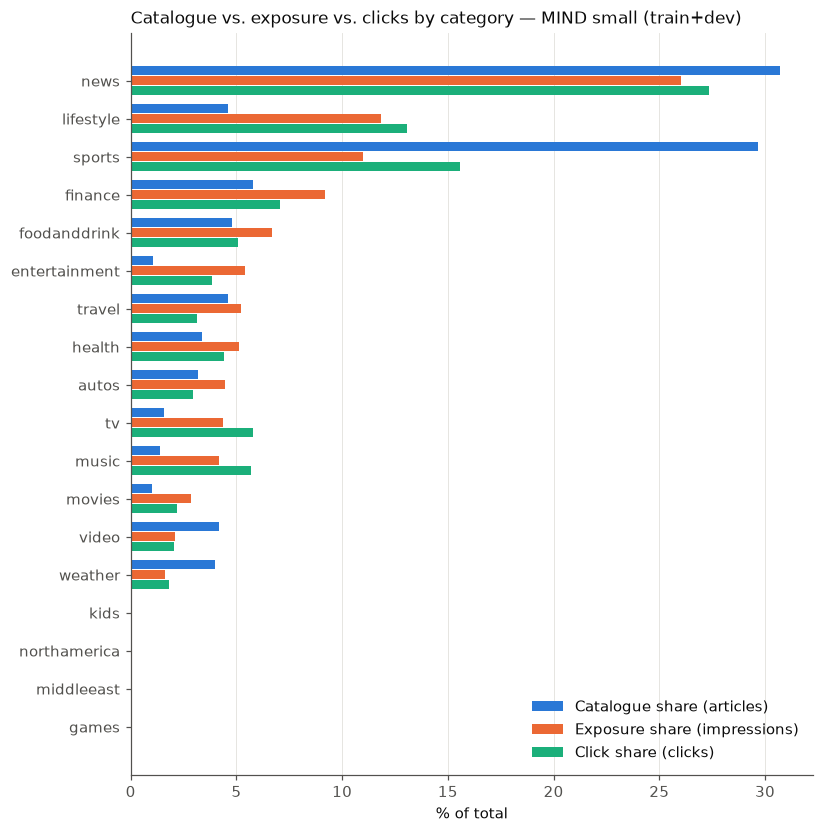

In [25]:
order = cat_tbl.sort_values("exposure_share").index
y = np.arange(len(order)); h = 0.26
fig, ax = plt.subplots(figsize=(8, 0.42 * len(order) + 1.2))
for i, (col, c, lab) in enumerate([("catalogue_share", C_CAT, "Catalogue share (articles)"),
                                   ("exposure_share", C_EXP, "Exposure share (impressions)"),
                                   ("click_share", C_CLK, "Click share (clicks)")]):
    ax.barh(y + (1 - i) * h, cat_tbl.loc[order, col] * 100, height=h - 0.03, color=c, label=lab)
ax.set_yticks(y, order); ax.set_xlabel("% of total"); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Catalogue vs. exposure vs. clicks by category — MIND small (train+dev)", loc="left", fontsize=11)
fig.savefig(FIGURES / "01_category_shares.png"); plt.show()

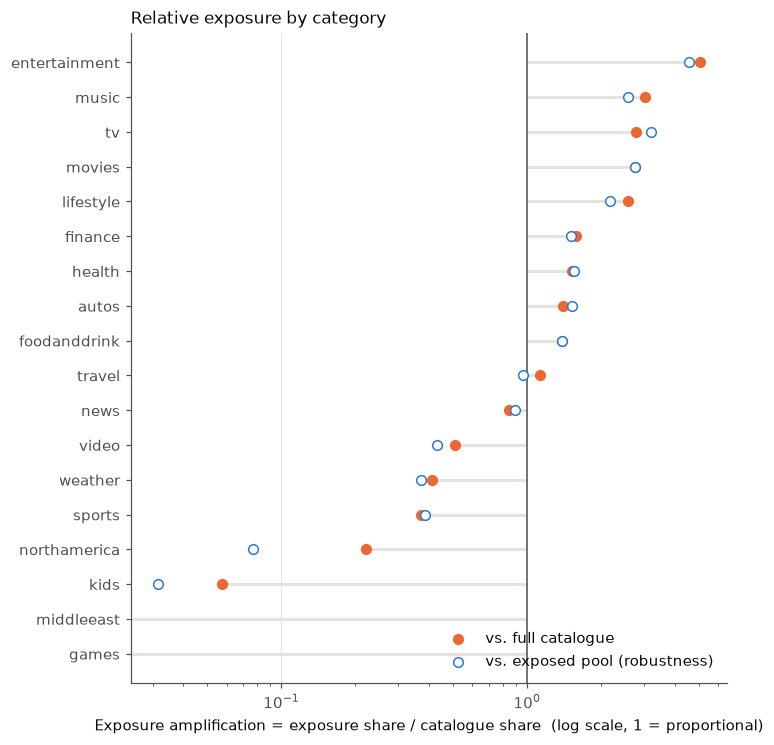

In [26]:
amp = cat_tbl[cat_tbl["n_articles"] > 0].sort_values("amplification")
fig, ax = plt.subplots(figsize=(7, 0.36 * len(amp) + 1.2))
ax.hlines(amp.index, 1, amp["amplification"], color=GRID, lw=2)
ax.scatter(amp["amplification"], amp.index, color=C_EXP, s=40, zorder=3, label="vs. full catalogue")
ax.scatter(amp["amplification_vs_pool"], amp.index, facecolor="white", edgecolor=C_CAT, s=40, zorder=3,
           label="vs. exposed pool (robustness)")
ax.axvline(1, color=INK2, lw=1); ax.set_xscale("log")
ax.set_xlabel("Exposure amplification = exposure share / catalogue share  (log scale, 1 = proportional)")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
ax.set_title("Relative exposure by category", loc="left", fontsize=11)
fig.savefig(FIGURES / "01_amplification.png"); plt.show()

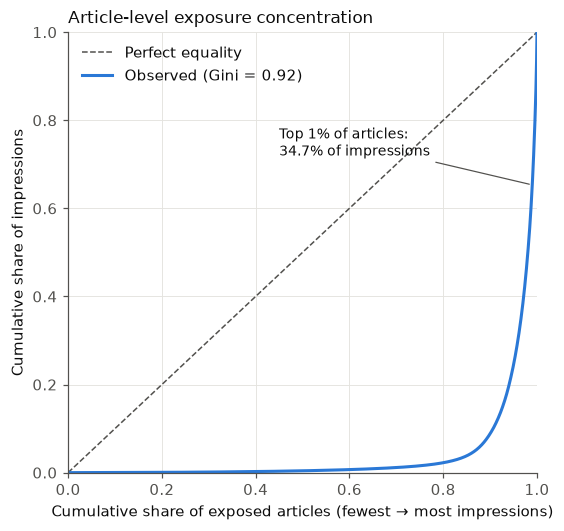

In [27]:
x, yv = M.lorenz_curve(imp)
g = M.gini(imp)
fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.plot([0, 1], [0, 1], color=INK2, lw=1, ls="--", label="Perfect equality")
ax.plot(x, yv, color=C_CAT, lw=2, label=f"Observed (Gini = {g:.2f})")
ax.set_xlabel("Cumulative share of exposed articles (fewest → most impressions)")
ax.set_ylabel("Cumulative share of impressions"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
t1 = M.top_share(imp, .01)["share_of_total"]
ax.annotate(f"Top 1% of articles:\n{t1:.1%} of impressions", xy=(0.99, 1 - t1), xytext=(0.45, 0.72),
            arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8), fontsize=9, color=INK)
ax.legend(loc="upper left"); ax.set_title("Article-level exposure concentration", loc="left", fontsize=11)
fig.savefig(FIGURES / "01_lorenz.png"); plt.show()

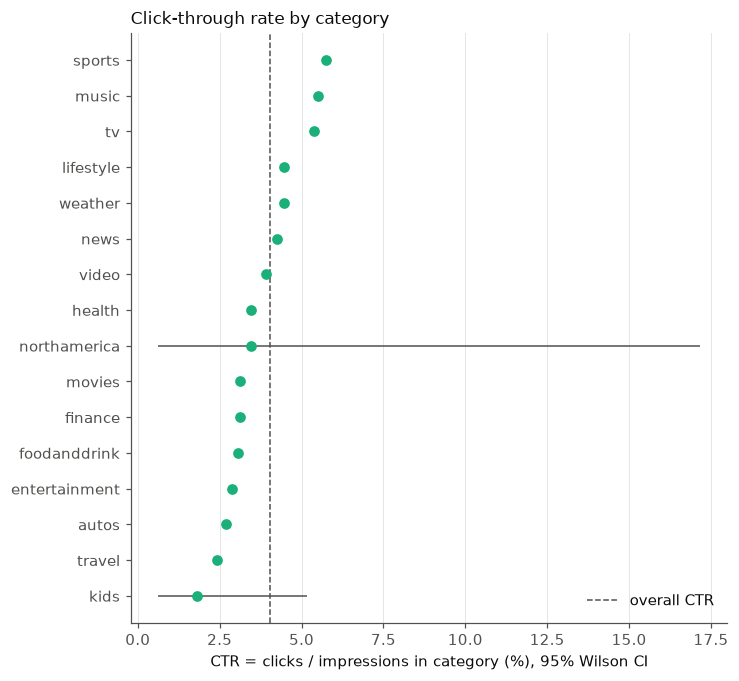

In [28]:
ctr_o = cat_tbl[cat_tbl["impressions"] > 0].sort_values("ctr")
fig, ax = plt.subplots(figsize=(7, 0.36 * len(ctr_o) + 1.2))
ax.errorbar(ctr_o["ctr"] * 100, ctr_o.index,
            xerr=[(ctr_o["ctr"] - ctr_o["ctr_ci_low"]) * 100, (ctr_o["ctr_ci_high"] - ctr_o["ctr"]) * 100],
            fmt="o", color=C_CLK, ecolor=INK2, elinewidth=1, ms=6)
ax.axvline(TOTAL_CLICKS / TOTAL_IMPRESSIONS * 100, color=INK2, lw=1, ls="--", label="overall CTR")
ax.set_xlabel("CTR = clicks / impressions in category (%), 95% Wilson CI"); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right"); ax.set_title("Click-through rate by category", loc="left", fontsize=11)
fig.savefig(FIGURES / "01_ctr_by_category.png"); plt.show()

## 11. Save results (with provenance)

In [29]:
cat_tbl.to_csv(RESULTS / "category_metrics.csv")
sub_tbl.to_csv(RESULTS / "subcategory_metrics.csv")
conc.to_csv(RESULTS / "concentration_metrics.csv", index=False)
art.to_csv(RESULTS / "article_exposure.csv")
pd.DataFrame({"news": news_val.astype(str).to_dict(), "behaviors": beh_val.astype(str).to_dict()}).to_json(
    RESULTS / "validation_01.json", indent=2)
(RESULTS / "anomalies_01.txt").write_text("\n".join(anomalies) + "\n")

POP = "MIND small, train+dev behaviors.tsv, all impressions joined to union news.tsv"
reg.add("rows_news_train", len(news["train"]), "rows", "MIND small train news.tsv")
reg.add("rows_news_dev", len(news["dev"]), "rows", "MIND small dev news.tsv")
reg.add("rows_behaviors_train", len(beh["train"]), "rows (impressions logs)", "MIND small train behaviors.tsv")
reg.add("rows_behaviors_dev", len(beh["dev"]), "rows (impressions logs)", "MIND small dev behaviors.tsv")
reg.add("unique_users", len(all_users), "unique user_id", "train ∪ dev behaviors.tsv")
reg.add("catalogue_articles", len(catalogue), "unique news_id", "train ∪ dev news.tsv")
reg.add("total_impressions", TOTAL_IMPRESSIONS, "exposure records (article shown in an impression)", POP,
        f"excluded {n_unjoined} unjoined records")
reg.add("unique_exposed_articles", UNIQUE_EXPOSED, "unique news_id shown ≥1 time", POP)
reg.add("total_clicks", TOTAL_CLICKS, "exposure records with label 1", POP)
reg.add("overall_ctr", TOTAL_CLICKS / TOTAL_IMPRESSIONS, "clicks / impressions", POP, unit="proportion")
reg.add("share_of_catalogue_ever_shown", len(art) / len(catalogue), "exposed articles / catalogue articles", POP,
        unit="proportion")

top_amp = cat_tbl[cat_tbl["n_articles"] >= MIN_ARTICLES].sort_values("amplification", ascending=False)
if top_amp.empty:
    print(f"WARNING: no category has ≥{MIN_ARTICLES} catalogue articles; amplification headlines skipped")
for name, row in ([("highest", top_amp.iloc[0]), ("lowest", top_amp.iloc[-1])] if len(top_amp) else []):
    reg.add(f"category_amplification_{name}", f"{row.name}: {row['amplification']:.3f}",
            "exposure share / catalogue share", POP, f"categories with ≥{MIN_ARTICLES} catalogue articles",
            notes=f"exposure_share={row['exposure_share']:.4f}, catalogue_share={row['catalogue_share']:.4f}, "
                  f"amplification_vs_pool={row['amplification_vs_pool']:.3f}")

main = conc.iloc[0]
for k in ["gini", "top_1pct_share", "top_5pct_share", "top_10pct_share", "bottom_50pct_share",
          "bottom_90pct_share", "frac_items_for_50pct"]:
    reg.add(f"article_exposure_{k}", main[k], "impressions per article", f"{int(main['n_items']):,} exposed articles, {POP}",
            "articles with ≥1 impression", unit="proportion")
reg.add("article_exposure_gini_full_catalogue", conc.iloc[1]["gini"], "impressions per article",
        "full catalogue incl. never-shown articles", "sensitivity analysis", unit="proportion")
reg.save(RESULTS / "headline_metrics.json")
reg.to_frame()[["metric", "value", "denominator", "filters"]]

,metric,value,denominator,filters
0,rows_news_train,51282,rows,none
1,rows_news_dev,42416,rows,none
2,rows_behaviors_train,156965,rows (impressions logs),none
3,rows_behaviors_dev,73152,rows (impressions logs),none
4,unique_users,94057,unique user_id,none
5,catalogue_articles,65238,unique news_id,none
6,total_impressions,8584442,exposure records (article shown in an impression),excluded 0 unjoined records
7,unique_exposed_articles,22771,unique news_id shown ≥1 time,none
8,total_clicks,347727,exposure records with label 1,none
9,overall_ctr,0.0405,clicks / impressions,none


## 12. Auto-generated FACT summary

In [30]:
# Sentences generated directly from computed values — the basis for the written interpretation.
c = cat_tbl
facts = [f"{len(catalogue):,} catalogue articles across {K_CATEGORIES} categories; {UNIQUE_EXPOSED:,} "
         f"({UNIQUE_EXPOSED/len(catalogue):.1%}) were shown at least once.",
         f"{TOTAL_IMPRESSIONS:,} impressions and {TOTAL_CLICKS:,} clicks (CTR {TOTAL_CLICKS/TOTAL_IMPRESSIONS:.2%})."]
for cat_name, r in c.head(5).iterrows():
    facts.append(f"'{cat_name}': {r['catalogue_share']:.1%} of catalogue, {r['exposure_share']:.1%} of impressions, "
                 f"{r['click_share']:.1%} of clicks; amplification {r['amplification']:.2f} "
                 f"(vs. exposed pool {r['amplification_vs_pool']:.2f}); CTR {r['ctr']:.2%}.")
facts.append(f"Top 1% of exposed articles received {main['top_1pct_share']:.1%} of impressions; top 10%: "
             f"{main['top_10pct_share']:.1%}; Gini {main['gini']:.3f}.")
print("\n".join(f"FACT: {f}" for f in facts))

FACT: 65,238 catalogue articles across 18 categories; 22,771 (34.9%) were shown at least once.
FACT: 8,584,442 impressions and 347,727 clicks (CTR 4.05%).
FACT: 'news': 30.7% of catalogue, 26.0% of impressions, 27.4% of clicks; amplification 0.85 (vs. exposed pool 0.90); CTR 4.26%.
FACT: 'lifestyle': 4.6% of catalogue, 11.8% of impressions, 13.1% of clicks; amplification 2.58 (vs. exposed pool 2.18); CTR 4.47%.
FACT: 'sports': 29.7% of catalogue, 11.0% of impressions, 15.6% of clicks; amplification 0.37 (vs. exposed pool 0.39); CTR 5.75%.
FACT: 'finance': 5.8% of catalogue, 9.2% of impressions, 7.1% of clicks; amplification 1.58 (vs. exposed pool 1.51); CTR 3.12%.
FACT: 'foodanddrink': 4.8% of catalogue, 6.7% of impressions, 5.1% of clicks; amplification 1.39 (vs. exposed pool 1.38); CTR 3.07%.
FACT: Top 1% of exposed articles received 34.7% of impressions; top 10%: 91.2%; Gini 0.921.


## 13. Interpretation

Reviewed against the executed outputs of this notebook (MIND small, train + dev, 8,584,442 impressions).
Format: **FACT** (printed above) → **INTERPRETATION** → **LIMITATION**.

**1. Exposure is not proportional to the catalogue, and the pattern survives both baselines.**
- FACT: entertainment is 1.1% of catalogue articles but 5.4% of impressions (amplification 5.08; 4.55 vs. the
  exposed pool). Music 3.02, TV 2.77, movies 2.75, lifestyle 2.58 (lifestyle: 4.6% of catalogue → 11.8% of impressions).
  Sports is 29.7% of the catalogue but 11.0% of impressions (0.37; 0.39 vs. pool); weather 0.41, video 0.51, news 0.85.
- INTERPRETATION: in the observed logs, entertainment/lifestyle-type categories receive roughly 2.5–5× their
  catalogue presence, while sports, weather and video receive well under half. The ranking is nearly identical
  under the exposed-pool baseline, so it is not an artefact of history-only articles in `news.tsv`.
- LIMITATION: amplification describes the output of MSN's whole ecosystem (editorial placement, page layout,
  recommendation, user navigation). It does not show intent, and "catalogue share" counts articles, not
  their importance or the number of distinct stories.

**2. Exposure tracks clicks only loosely at category level.**
- FACT: sports has the highest CTR (5.75%) yet the lowest amplification among large categories; entertainment
  has one of the lowest CTRs (2.88%) yet the highest amplification. Across the 14 categories with ≥50 articles,
  Spearman ρ(amplification, CTR) = −0.08 (p = 0.78).
- INTERPRETATION: category-level exposure is not explained by category-level click-through in these logs —
  consistent with exposure being shaped by factors beyond observed engagement rates.
- LIMITATION: n = 14 categories; CTR here is conditional on the logging design (see Limitations: every logged
  impression contains ≥1 click). Not causal.

**3. Article-level exposure is extremely concentrated.**
- FACT: among the 22,771 articles shown at least once, Gini = 0.92; the top 1% (228 articles) received 34.7% of
  impressions and the top 10% received 91.2%; the bottom 50% received 0.4%. 1.95% of articles account for half
  of all impressions. Within single days, Gini is 0.89–0.93.
- INTERPRETATION: a very small set of articles captures most of the logged exposure. Because the concentration
  holds within each day, it is not only an effect of articles being published at different times.
- LIMITATION: the top-1% articles also have a higher pooled CTR (5.38% vs. 3.31% for other articles with
  ≥100 impressions), though the article-level rank correlation is weak (ρ = 0.06). Concentration may partly
  reflect demand; the observational data cannot separate the two.

**4. Most of the catalogue is never shown.**
- FACT: 34.9% of the 65,238 catalogue articles appear in at least one impression; the remaining 65.1% appear only
  in users' pre-period click histories.
- INTERPRETATION: `news.tsv` is mostly a record of older content, not the candidate pool during the logged week.
- LIMITATION: this is why the exposed-pool baseline is always reported next to catalogue share.

## 14. Limitations

- **Click-conditioned logs.** Every logged impression in MIND small contains at least one click (validation:
  0 zero-click impressions in train or dev). CTR values are therefore conditional on sessions with engagement
  and overstate CTR across all MSN page views. Compare CTRs across categories only, never to external benchmarks.
- **Exposure proxy.** An impression means an article was logged as shown, not that it was seen or read.
  The order inside an impression list is not documented as display rank.
- **Catalogue definition.** 65.1% of `news.tsv` articles appear only in click histories (older content). Amplification
  vs. the full catalogue mixes availability with selection; the exposed-pool baseline (which conditions on being shown)
  is reported alongside, and both give the same ranking.
- **Short window.** Train covers 9–14 Nov 2019 and dev covers 15 Nov 2019; category shares shift between the two
  (largest: news 27.2% train vs. 23.4% dev), so single-week results may not generalise across time.
- **Sampled users.** Train and dev are largely different user samples (50,000 each, 5,943 in both).
- **Small categories.** kids (22 articles), middleeast (2), northamerica (1) and games (1) are too small for
  meaningful ratios and are excluded from headline claims.
- **Observed system ≠ algorithm.** Impressions result from MSN's whole ecosystem. Patterns are descriptive and do not
  establish intent or unfairness.
- **Scope.** US Microsoft News only; not representative of other platforms, countries, or Canadian audiences.
- **No demographics.** Users are anonymized; no demographic or geographic user analysis is possible or attempted.